In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import seaborn as sns
from scipy import stats

import inspect

from rwmcmc.targets import banana_log_pdf
from rwmcmc.samplers import random_walk_metropolis_hastings


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [8, 5]   # default boyut

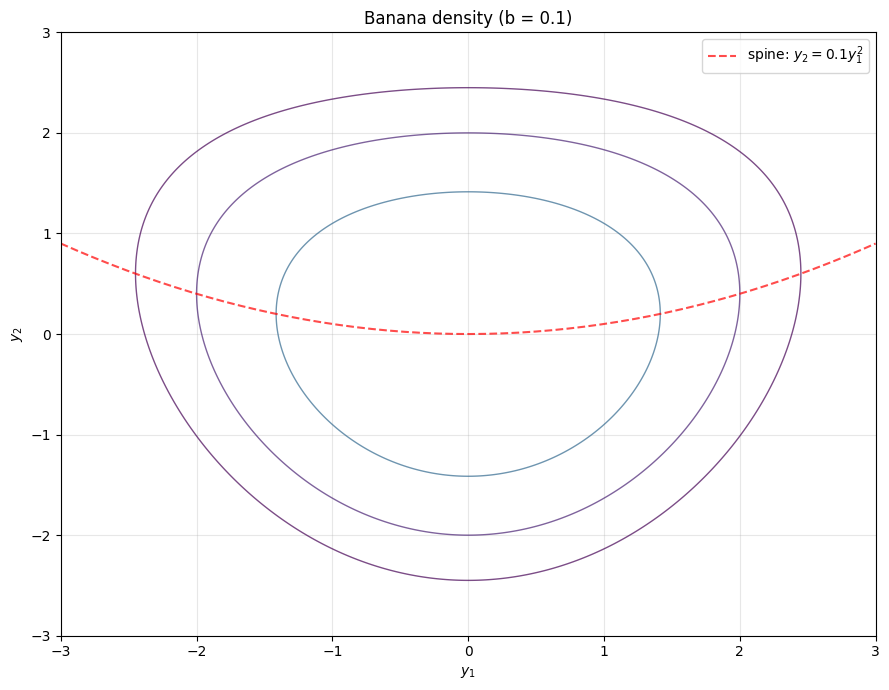

In [5]:
# 2D evaluation grid
sig = inspect.signature(banana_log_pdf)
b_default = sig.parameters['b'].default

y1_max = 3.0
y2_max = max(b_default * y1_max**2 + 3, 5)  # +3 yer ver kuyruk için
y1_grid = np.linspace(-y1_max, y1_max, 300)
y2_grid = np.linspace(-3, y2_max-2, 300)

Y1, Y2 = np.meshgrid(y1_grid, y2_grid)
xy = np.stack([Y1, Y2], axis=-1)  # shape (300, 300, 2)

log_p = banana_log_pdf(xy)         # (300, 300)
p = np.exp(log_p)                  # unnormalized density

sig = inspect.signature(banana_log_pdf)
b_default = sig.parameters['b'].default

# Spine is the centerline of the banana-shaped distribution, where the density is highest.
# Spine: y_2 = 0.1 * y_1^2
y1_spine = np.linspace(-y1_max, y1_max, 200)
y2_spine = b_default * y1_spine ** 2

fig, ax = plt.subplots(figsize=(9, 7))

# Contour levels
levels = np.exp(np.linspace(log_p.max() - 3, log_p.max(), 4))
cs = ax.contour(Y1, Y2, p, levels=levels, linewidths=1., alpha=0.7)

# Spine'i vurgu
ax.plot(y1_spine, y2_spine, "r--", linewidth=1.5, alpha=0.7,
        label=r"spine: $y_2 = 0.1 y_1^2$")

ax.set_xlabel(r"$y_1$")
ax.set_ylabel(r"$y_2$")
ax.set_title("Banana density (b = 0.1)")
ax.set_aspect("auto")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
rng = np.random.default_rng(seed=42)

samples, accepted = random_walk_metropolis_hastings(
    target_log_pdf=banana_log_pdf,
    x0=[0.0, 0.0],
    n_samples=10_000,
    step_size=0.5,
    rng=rng,
)

print(f"Samples shape:   {samples.shape}")
print(f"Acceptance rate: {accepted.mean():.3f}")
print(f"y_1 sample mean: {samples[:, 0].mean():.4f}  (true: 0.0)")
print(f"y_2 sample mean: {samples[:, 1].mean():.4f}  (true: 0.1)")
print(f"y_1 sample std:  {samples[:, 0].std():.4f}  (true: 1.0)")
print(f"y_2 sample std:  {samples[:, 1].std():.4f}  (true: ~1.02)")

Samples shape:   (10000, 2)
Acceptance rate: 0.757
y_1 sample mean: 0.0707  (true: 0.0)
y_2 sample mean: 0.0828  (true: 0.1)
y_1 sample std:  0.9850  (true: 1.0)
y_2 sample std:  1.0487  (true: ~1.02)


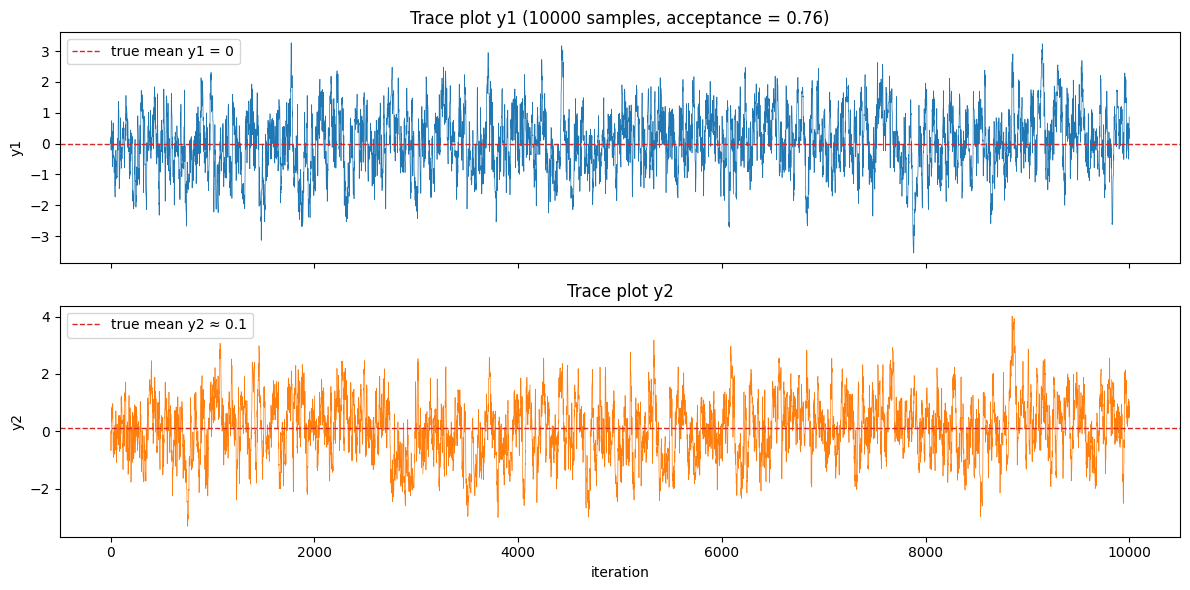

In [7]:


fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Trace for y1
axes[0].plot(samples[:, 0], linewidth=0.5, color="C0")
axes[0].axhline(0, color="C3", linestyle="--", linewidth=1, label="true mean y1 = 0")
axes[0].set_ylabel("y1")
axes[0].set_title(f"Trace plot y1 ({len(samples)} samples, acceptance = {accepted.mean():.2f})")
axes[0].legend()

# Trace for y2
axes[1].plot(samples[:, 1], linewidth=0.5, color="C1")
axes[1].axhline(0.1, color="C3", linestyle="--", linewidth=1, label="true mean y2 ≈ 0.1")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("y2")
axes[1].set_title(f"Trace plot y2")
axes[1].legend()

plt.tight_layout()
plt.show()

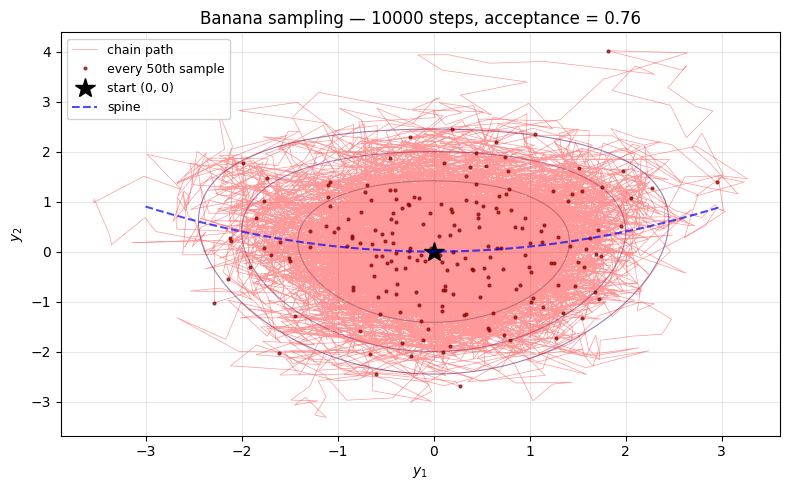

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

# Background contour
ax.contour(Y1, Y2, p, levels=levels, cmap="viridis", linewidths=0.8, alpha=0.5)

# Chain trajectory
ax.plot(samples[:, 0], samples[:, 1], "-", color="red", linewidth=0.5, alpha=0.4,
        label="chain path")

# Thinning (every 50th sample)
thin = samples[::50]
ax.plot(thin[:, 0], thin[:, 1], ".", color="darkred", markersize=4, alpha=0.7,
        label="every 50th sample")

# Start
ax.plot(samples[0, 0], samples[0, 1], "k*", markersize=15, label="start (0, 0)")

# Spine
ax.plot(y1_spine, y2_spine, "b--", linewidth=1.5, alpha=0.7, label="spine")

ax.set_xlabel(r"$y_1$")
ax.set_ylabel(r"$y_2$")
ax.set_title(f"Banana sampling — {len(samples)} steps, acceptance = {accepted.mean():.2f}")
ax.set_aspect("auto")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

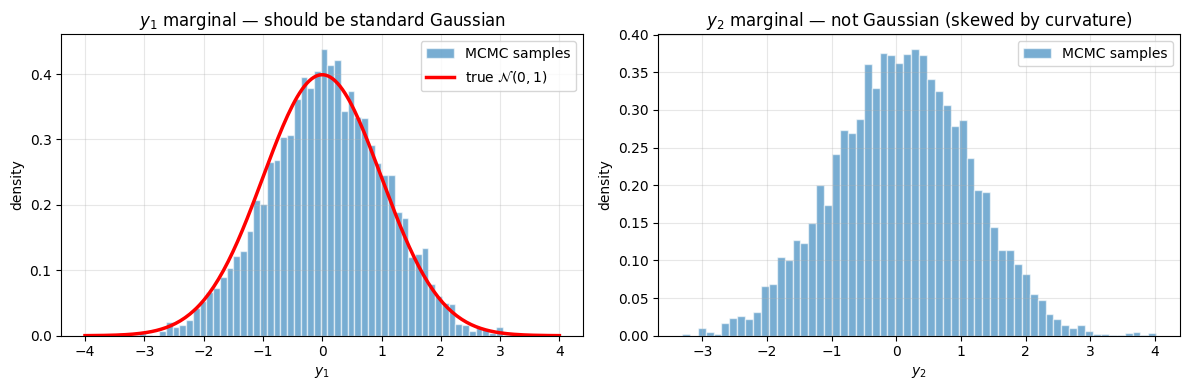

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# y_1 marjinali — TRUE N(0, 1)
axes[0].hist(samples[:, 0], bins=60, density=True, alpha=0.6, color="C0",
             edgecolor="white", label="MCMC samples")
y1_range = np.linspace(-4, 4, 200)
axes[0].plot(y1_range, np.exp(-0.5 * y1_range ** 2) / np.sqrt(2 * np.pi),
             "r-", linewidth=2.5, label=r"true $\mathcal{N}(0, 1)$")
axes[0].set_xlabel(r"$y_1$")
axes[0].set_ylabel("density")
axes[0].set_title(r"$y_1$ marginal — should be standard Gaussian")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# y_2 marjinali — NOT Gaussian; right-skewed
axes[1].hist(samples[:, 1], bins=60, density=True, alpha=0.6, color="C0",
             edgecolor="white", label="MCMC samples")
axes[1].set_xlabel(r"$y_2$")
axes[1].set_ylabel("density")
axes[1].set_title(r"$y_2$ marginal — not Gaussian (skewed by curvature)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

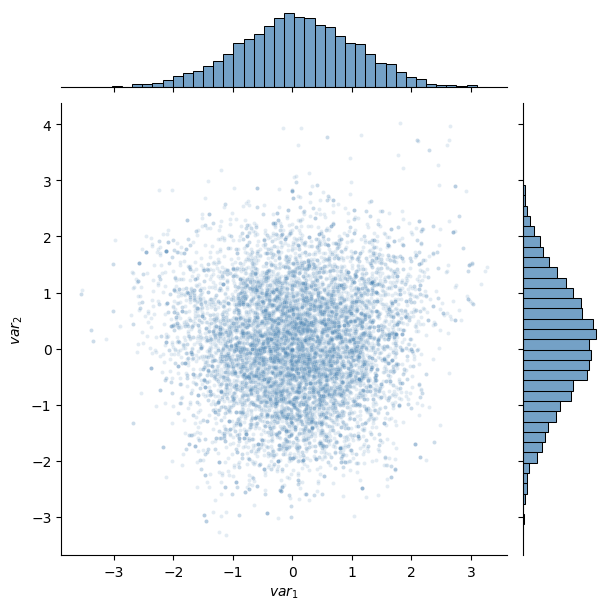

In [15]:

# Draw a plot for the joint distribution as in the https://jakevdp.github.io/blog/2015/08/07/frequentism-and-bayesianism-5-model-selection/
g = sns.jointplot(x=samples[:, 0], y=samples[:, 1], kind="scatter",
                  s=8, alpha=0.15, color="steelblue", height=6,
                  marginal_kws=dict(bins=40))
g.set_axis_labels(r"$var_1$", r"$var_2$")

r, p = stats.pearsonr(samples[:, 0], samples[:, 1])


plt.show()